Lab 4

In [1]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
mode = "rgb_array"
if mode == "Node":
    mode = None

(10, 1, 0)


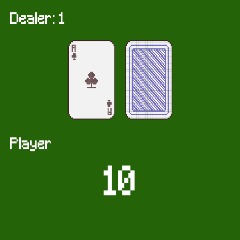

In [2]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [3]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [4]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [5]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((20, 1, 0), 0.0, False, False)

In [6]:
env.close()

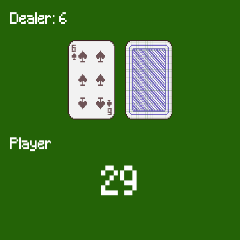

nagroda = -1.0, liczba punktów graczy = 29


In [7]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [8]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

1, obserwation, (13, 10, 0), 0.0, False
0, obserwation, (13, 10, 0), -1.0, True
nagroda = -1.0, liczba punktów gracza = 13, liczba punktów przeciwnika = 10


Car racing do wywalenia



In [9]:
!pip install gymnasium[box2d] torch torchvision --quiet
!pip install box2d-py --quiet
import gymnasium as gym
import numpy as np
import random
import math
import time
from collections import deque
from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Urządzenie: {device}')
print(f'gymnasium: {gym.__version__}')
print(f'PyTorch:   {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 113.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.5/374.5 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Urządzenie: cuda
gymnasium: 1.3.0
PyTorch:   2.10.0+cu128


Przestrzeń obserwacji: Box(0, 255, (96, 96, 3), uint8)
Przestrzeń akcji:      Discrete(5)
Znaczenie akcji:
  0: NOP (nic)
  1: Lewo
  2: Prawo
  3: Gaz
  4: Hamulec


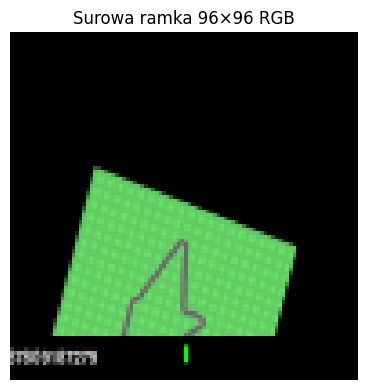

In [10]:
env = gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array')

print('Przestrzeń obserwacji:', env.observation_space)
print('Przestrzeń akcji:     ', env.action_space)
print('Znaczenie akcji:')
for i, name in enumerate(['NOP (nic)', 'Lewo', 'Prawo', 'Gaz', 'Hamulec']):
    print(f'  {i}: {name}')

obs, info = env.reset(seed=42)

import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.imshow(obs)
plt.title('Surowa ramka 96×96 RGB')
plt.axis('off')
plt.tight_layout()
plt.show()

env.close()

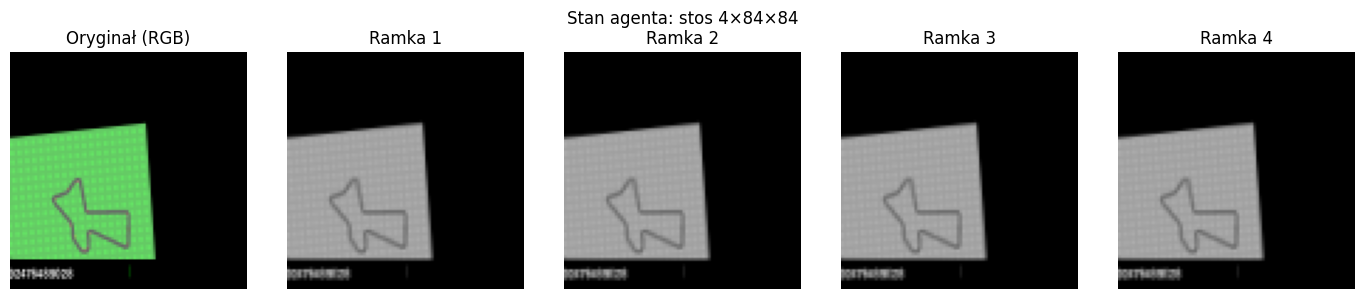

In [11]:
FRAME_SIZE = 84
STACK_SIZE = 4


def preprocess_frame(frame: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (FRAME_SIZE, FRAME_SIZE), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0


class FrameStack:
    def __init__(self, k: int = STACK_SIZE):
        self.k = k
        self.frames: deque = deque(maxlen=k)

    def reset(self, first_frame: np.ndarray) -> np.ndarray:
        proc = preprocess_frame(first_frame)
        for _ in range(self.k):
            self.frames.append(proc)
        return self._get_state()

    def step(self, frame: np.ndarray) -> np.ndarray:
        self.frames.append(preprocess_frame(frame))
        return self._get_state()

    def _get_state(self) -> np.ndarray:
        return np.stack(list(self.frames), axis=0)


# Podgląd
env = gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array')
obs, _ = env.reset(seed=0)
fs = FrameStack()
state = fs.reset(obs)

fig, axes = plt.subplots(1, STACK_SIZE + 1, figsize=(14, 3))
axes[0].imshow(obs)
axes[0].set_title('Oryginał (RGB)')
axes[0].axis('off')
for i in range(STACK_SIZE):
    axes[i + 1].imshow(state[i], cmap='gray', vmin=0, vmax=1)
    axes[i + 1].set_title(f'Ramka {i+1}')
    axes[i + 1].axis('off')
plt.suptitle(f'Stan agenta: stos {STACK_SIZE}×{FRAME_SIZE}×{FRAME_SIZE}')
plt.tight_layout()
plt.show()
env.close()

In [12]:
class DQN(nn.Module):
    def __init__(self, n_actions: int = 5):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(STACK_SIZE, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        dummy = torch.zeros(1, STACK_SIZE, FRAME_SIZE, FRAME_SIZE)
        conv_out = int(np.prod(self.conv(dummy).shape[1:]))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_out, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(self.conv(x))


net = DQN().to(device)
dummy_state = torch.zeros(1, STACK_SIZE, FRAME_SIZE, FRAME_SIZE, device=device)
q_vals = net(dummy_state)
print('Kształt Q-wartości:', q_vals.shape)
print(f'Parametry sieci:    {sum(p.numel() for p in net.parameters()):,}')

Kształt Q-wartości: torch.Size([1, 5])
Parametry sieci:    1,686,693


In [13]:
@dataclass
class Transition:
    state:      np.ndarray
    action:     int
    reward:     float
    next_state: np.ndarray
    done:       bool


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer: deque = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states      = torch.tensor(np.array([t.state      for t in batch]), dtype=torch.float32, device=device)
        actions     = torch.tensor([t.action     for t in batch], dtype=torch.long,    device=device)
        rewards     = torch.tensor([t.reward     for t in batch], dtype=torch.float32, device=device)
        next_states = torch.tensor(np.array([t.next_state for t in batch]), dtype=torch.float32, device=device)
        dones       = torch.tensor([t.done       for t in batch], dtype=torch.float32, device=device)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


print('ReplayBuffer gotowy.')

ReplayBuffer gotowy.


In [14]:
GAMMA         = 0.99
LR            = 1e-4
BATCH_SIZE    = 32
BUFFER_CAP    = 50_000
MIN_BUFFER    = 5_000
TARGET_UPDATE = 1_000
EPS_START     = 1.0
EPS_END       = 0.05
EPS_DECAY     = 200_000
MAX_EPISODES  = 300
MAX_STEPS     = 1_000


class DQNAgent:
    def __init__(self, n_actions: int = 5):
        self.n_actions   = n_actions
        self.q_net       = DQN(n_actions).to(device)
        self.target_net  = DQN(n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer   = optim.Adam(self.q_net.parameters(), lr=LR)
        self.memory      = ReplayBuffer(BUFFER_CAP)
        self.steps       = 0

    def select_action(self, state: np.ndarray) -> int:
        eps = EPS_END + (EPS_START - EPS_END) * math.exp(-self.steps / EPS_DECAY)
        self.steps += 1
        if random.random() < eps:
            return random.randrange(self.n_actions)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            return self.q_net(s).argmax(dim=1).item()

    def update(self) -> Optional[float]:
        if len(self.memory) < MIN_BUFFER:
            return None
        s, a, r, s2, done = self.memory.sample(BATCH_SIZE)
        q_pred   = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            q_next   = self.target_net(s2).max(dim=1).values
            q_target = r + GAMMA * q_next * (1.0 - done)
        loss = F.smooth_l1_loss(q_pred, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()
        if self.steps % TARGET_UPDATE == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        return loss.item()

    def current_eps(self) -> float:
        return EPS_END + (EPS_START - EPS_END) * math.exp(-self.steps / EPS_DECAY)


print('Agent DQN gotowy.')

Agent DQN gotowy.


In [15]:
env = gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array')
agent = DQNAgent(n_actions=env.action_space.n)
frame_stack = FrameStack()

episode_rewards = []
episode_lengths = []
losses = []
best_reward = -np.inf
start_time = time.time()

print(f'{"Epizod":>8} | {"Nagroda":>10} | {"Kroki":>7} | {"ε":>6} | {"Strata":>10} | Czas')
print('-' * 65)

for episode in range(1, MAX_EPISODES + 1):
    obs, _ = env.reset()
    state  = frame_stack.reset(obs)
    total_reward = 0.0
    ep_loss = []

    for step in range(MAX_STEPS):
        action = agent.select_action(state)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = frame_stack.step(obs)
        agent.memory.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        loss = agent.update()
        if loss is not None:
            ep_loss.append(loss)
        if done:
            break

    episode_rewards.append(total_reward)
    episode_lengths.append(step + 1)
    mean_loss = np.mean(ep_loss) if ep_loss else float('nan')
    losses.append(mean_loss)

    if total_reward > best_reward:
        best_reward = total_reward
        torch.save(agent.q_net.state_dict(), 'best_dqn_car.pth')

    if episode % 10 == 0:
        avg_r   = np.mean(episode_rewards[-10:])
        elapsed = time.time() - start_time
        print(f'{episode:>8} | {avg_r:>10.1f} | {step+1:>7} | {agent.current_eps():>6.3f} | {mean_loss:>10.4f} | {elapsed:.0f}s')

env.close()
print(f'\nNajlepsza nagroda: {best_reward:.1f}')

  Epizod |    Nagroda |   Kroki |      ε |     Strata | Czas
-----------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
def moving_avg(arr, w=20):
    return np.convolve(arr, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_rewards, alpha=0.3, color='steelblue', label='epizod')
if len(episode_rewards) >= 20:
    axes[0].plot(range(19, len(episode_rewards)), moving_avg(episode_rewards),
                 color='navy', linewidth=2, label='MA-20')
axes[0].set_title('Nagroda per epizod')
axes[0].set_xlabel('Epizod')
axes[0].set_ylabel('Nagroda')
axes[0].legend()
axes[0].grid(alpha=0.3)

valid_losses = [(i, l) for i, l in enumerate(losses) if not np.isnan(l)]
if valid_losses:
    xi, yi = zip(*valid_losses)
    axes[1].plot(xi, yi, alpha=0.4, color='tomato')
    if len(yi) >= 20:
        axes[1].plot(list(xi)[19:], moving_avg(list(yi)), color='darkred', linewidth=2)
axes[1].set_title('Strata Hubera (DQN)')
axes[1].set_xlabel('Epizod')
axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)

axes[2].plot(episode_lengths, alpha=0.4, color='seagreen')
if len(episode_lengths) >= 20:
    axes[2].plot(range(19, len(episode_lengths)), moving_avg(episode_lengths),
                 color='darkgreen', linewidth=2)
axes[2].set_title('Długość epizodu (kroki)')
axes[2].set_xlabel('Epizod')
axes[2].set_ylabel('Kroki')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
agent.q_net.load_state_dict(torch.load('best_dqn_car.pth', map_location=device))
agent.q_net.eval()

N_EVAL = 5
eval_rewards = []
eval_env = gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array')
frame_stack_eval = FrameStack()

for ep in range(N_EVAL):
    obs, _ = eval_env.reset(seed=ep * 100)
    state  = frame_stack_eval.reset(obs)
    total  = 0.0
    frames_to_show = []

    for step in range(MAX_STEPS):
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            action = agent.q_net(s).argmax(dim=1).item()
        obs, reward, terminated, truncated, _ = eval_env.step(action)
        state  = frame_stack_eval.step(obs)
        total += reward
        if ep == 0 and step % 50 == 0:
            frames_to_show.append(eval_env.render())
        if terminated or truncated:
            break

    eval_rewards.append(total)
    print(f'Epizod {ep+1}: nagroda = {total:.1f}')

eval_env.close()
print(f'\nŚrednia: {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}')

if frames_to_show:
    n = len(frames_to_show)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    if n == 1: axes = [axes]
    for i, f in enumerate(frames_to_show):
        axes[i].imshow(f)
        axes[i].set_title(f'Krok {i*50}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

Taxi

212


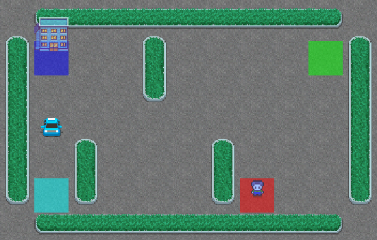

In [18]:
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode='rgb_array') # rgb_array

#observation, info = env.reset()
observation, _ = env.reset()
print(f"{observation}")
img = env.render();
w, h, _ = img.shape
ratio = h/w                 # !!!
new_w, new_h = int(ratio* 240), 240 # !!!
cv2_imshow( cv2.resize(img, (new_w, new_h)) ) # OpenCV
#env.close()

In [19]:
env.action_space, env.observation_space

(Discrete(6), Discrete(500))

In [29]:
def flatten_state(env, obs):
    print(f"# [ info ] {obs}")
    if isinstance(obs, int):
        return obs
    else:
        ans = obs[0];
        prod = 1;
        for n in range(1, len(obs)):
            prod *= env.observation_space[n-1].n
            ans += prod*obs[n]
            #print(f"{prod*obs[n], prod}")
        return ans

observation, _ = env.reset()
flatten_state(env, observation)

# [ info ] 464


464